# BSM: Lorentz-invariance violation

Some extensions of the Standard Model -- string-inspired constructions, models
with a preferred frame, effective descriptions of quantum gravity -- break
Lorentz invariance. If they do, neutrinos are an unusually good place to look:
oscillations measure a *phase*, and a phase accumulated over an astrophysical
baseline is sensitive to energies that no accelerator reaches.

Mag$\nu$s treats this as an extra, CPT-odd term in the Hamiltonian,

$$\mathbf{H} = \frac{1}{2E}\,\mathbf{U}\,\mathbf{M}^2\,\mathbf{U}^\dagger
             \;+\; \mathbf{V}_{\rm CC}
             \;+\; E^{\,n}\,
               \mathbf{U}_\xi\,
               \frac{\mathbf{B}}{\Lambda^{\,n}}\,
               \mathbf{U}_\xi^\dagger ,$$

where $\mathbf{B} = {\rm diag}(b_1, b_2, b_3)$ holds the eigenvalues of the LIV
operator, $\mathbf{U}_\xi$ rotates from its eigenbasis to the flavour basis
through angles $\xi_{12}, \xi_{23}, \xi_{13}$ and a phase $\delta_{\xi\rm CP}$,
$\Lambda$ is the scale that makes the eigenvalues dimensionless, and $n$ is the
operator's dimension minus three.

## Why the exponent is the whole story

Look at how the three terms scale with energy:

| term | scaling | behaviour at high $E$ |
|---|---|---|
| vacuum | $\Delta m^2 / 2E \;\propto\; E^{-1}$ | switches **off** |
| matter | $V_{\rm CC}$, independent of $E$ | flat |
| LIV | $E^{\,n}\, b/\Lambda^{\,n}$ | switches **on** (for $n \geq 0$) |

Standard oscillations die away at high energy: the phase $\Delta m^2 L / 2E$
shrinks, and the probability freezes at its zero-baseline value. A LIV term
does the opposite. So the signature is not that oscillations look slightly
different -- it is that they are still *there*, at energies where the Standard
Model says they should have stopped.

That is what the figures below show, and it is why every one of them is plotted
against energy.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

## 1. The interface

Every `osc_prob_{2,3,4,5}nu_*` family has a `_liv` counterpart -- in vacuum, in
constant- and exponential-density matter, inside the Earth, and inside the Sun:

In [3]:
[n for n in dir(oscprob) if n.startswith('osc_prob') and n.endswith('liv')]

['osc_prob_2nu_earth_liv',
 'osc_prob_2nu_sun_liv',
 'osc_prob_2nu_vacuum_liv',
 'osc_prob_3nu_earth_liv',
 'osc_prob_3nu_sun_liv',
 'osc_prob_3nu_vacuum_liv',
 'osc_prob_4nu_earth_liv',
 'osc_prob_4nu_sun_liv',
 'osc_prob_4nu_vacuum_liv',
 'osc_prob_5nu_earth_liv',
 'osc_prob_5nu_sun_liv',
 'osc_prob_5nu_vacuum_liv',
 'osc_prob_liv']

They take the standard mixing parameters plus the LIV ones. For three
flavours those are `sxi12`, `sxi23`, `sxi13`, `dxiCP` (the mixing of the LIV
eigenbasis into flavour), `b1`, `b2`, `b3` (its eigenvalues), `Lambda`, and
`n_liv`.

We use NuFIT 6.1 for the standard parameters, and a baseline equal to the
Earth's diameter -- the longest a terrestrial experiment can have, and the one
atmospheric-neutrino detectors actually use:

In [4]:
osc = gd.load_nufit_params('NuFIT 6.1')

L_km = 1.3e4                                  # Earth diameter [km]
L = L_km*gd.CONV_KM_TO_INV_EV                 # [eV^-1]

nu_i, nu_f = gd.NUMU, gd.NUMU                 # muon-neutrino survival
energies = np.logspace(0.0, 4.0, 700)         # [GeV]  (below ~1 GeV the
                                              #  oscillation is faster than
                                              #  any practical grid resolves)
E = energies*gd.UNIT_GEV                      # [eV]

# Only b3 is switched on, and only the 2-3 sector is rotated, so the LIV term
# acts in the same sector as atmospheric oscillations -- the cleanest case to
# compare against.
liv = dict(sxi12=0.0, sxi23=1.0/np.sqrt(2.0), sxi13=0.0, dxiCP=0.0,
           b1=0.0, b2=0.0, Lambda=1.0)

# Choose b3 so the LIV phase b3*E^n*L reaches ~pi at E_star: that is where the
# term stops being a correction and starts driving the oscillation.
E_star = 1.0e2*gd.UNIT_GEV
def b3_for(n_liv, E_star=E_star, L=L):
    '''The eigenvalue whose LIV phase reaches pi at E_star.'''
    return np.pi/(L*E_star**n_liv)

print(f'L        = {L:.3e} eV^-1  ({L_km:.0f} km)')
for n in (0, 1, 2):
    print(f'n_liv={n}: b3 = {b3_for(n):.3e} eV^(1-{n})')

L        = 6.588e+13 eV^-1  (13000 km)
n_liv=0: b3 = 4.769e-14 eV^(1-0)
n_liv=1: b3 = 4.769e-25 eV^(1-1)
n_liv=2: b3 = 4.769e-36 eV^(1-2)


## 2. Where standard oscillations stop and LIV keeps going

The defining figure. Below a few GeV the two curves agree -- the LIV term is
still negligible there. Above the crossover the standard curve flattens to 1,
because the vacuum phase has shrunk below one radian, while the LIV curve keeps
oscillating with a phase that is still growing.

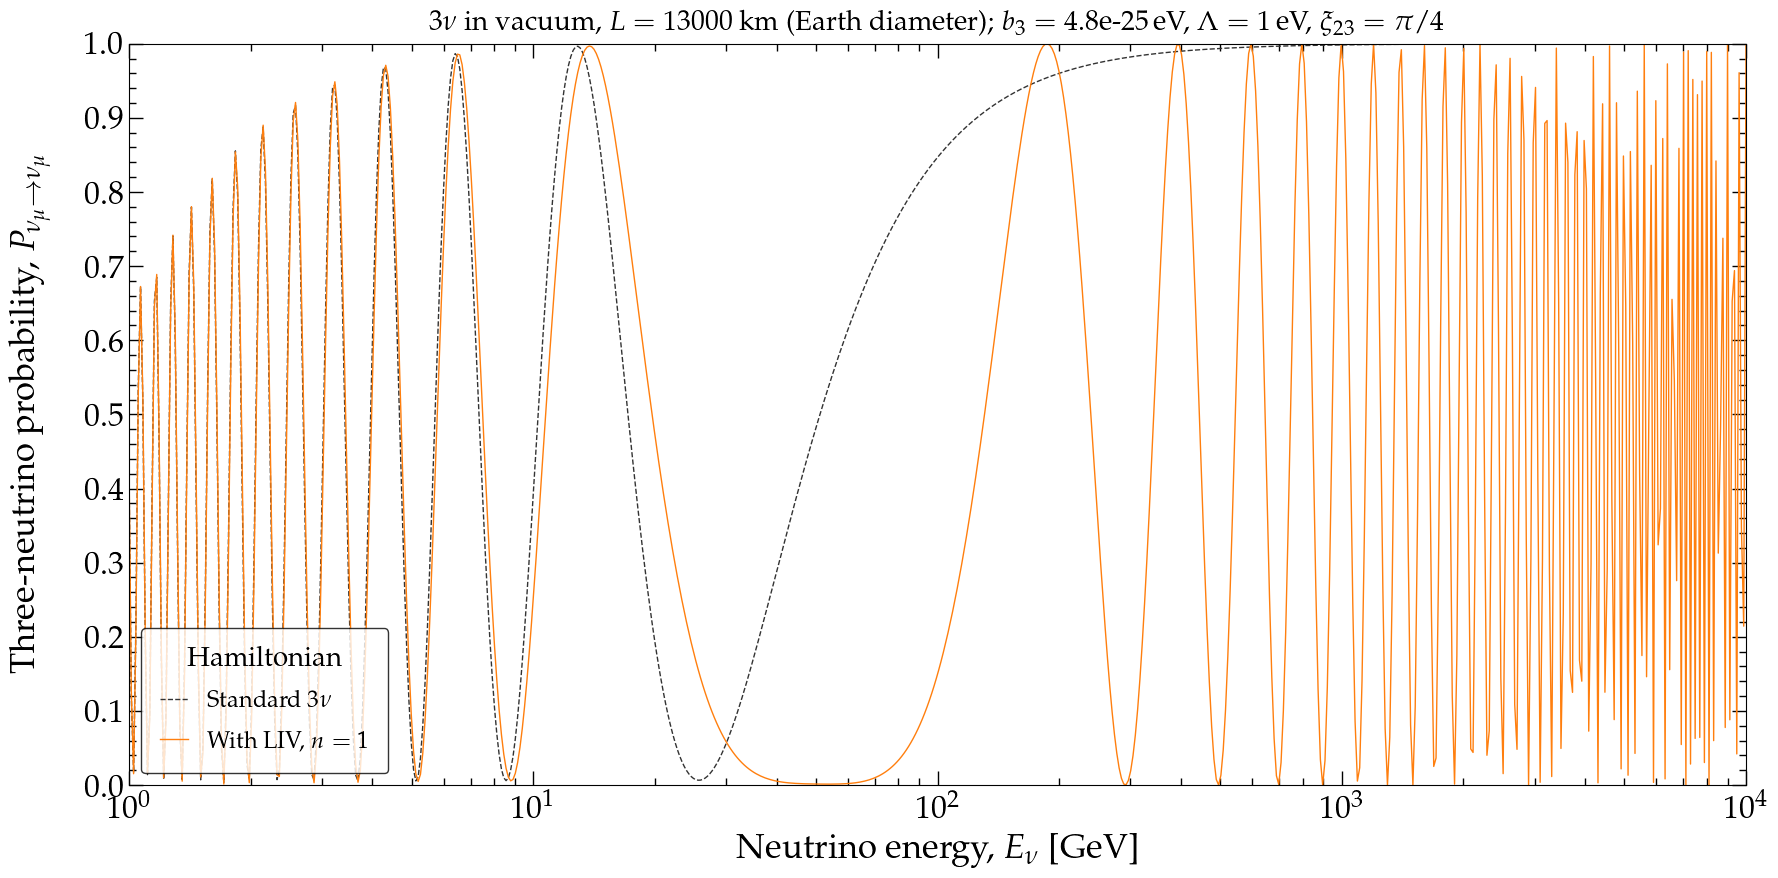

In [5]:
n_liv = 1
b3 = b3_for(n_liv)

prob_std = oscprob.osc_prob_3nu_vacuum(E, L, **osc, nu_i=nu_i, nu_f=nu_f)
prob_liv = oscprob.osc_prob_3nu_vacuum_liv(E, L, **osc, **liv, b3=b3, n_liv=n_liv,
                                           nu_i=nu_i, nu_f=nu_f)

fig, ax = plotting.plot_probability_vs_energy(
    energies,
    [dict(y=prob_std, label=r'Standard $3\nu$', color='0.2', ls='--'),
     dict(y=prob_liv, label=r'With LIV, $n = 1$', color='C1')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=3,
    xlim=(energies[0], energies[-1]),
    legend_title=r'Hamiltonian', legend_loc='lower left',
    title=(r'$3\nu$~in vacuum, $L = $~{:.0f}~km (Earth diameter);  '.format(L_km)
           + r'$b_3 = $ ' + '{:.1e}'.format(b3)
           + r'$\,$eV, $\Lambda = 1\,$eV, $\xi_{23} = \pi/4$'))

Read the flat part of the dashed curve as the Standard Model's prediction:
*nothing happens up here*. Any oscillation observed in that region cannot come
from mass-squared differences, whatever their values, because the $1/E$ has
already switched them off. That is what makes the high-energy tail the place to
look, and why the strongest limits on LIV come from atmospheric and
astrophysical neutrinos rather than from beam experiments.

## 3. The operator dimension sets where it turns on

`n_liv` is the operator's dimension minus three, so $n = 0$ is a
dimension-three (CPT-odd mass-like) term, $n = 1$ dimension four, and so on.

Each curve below is normalised to the *same* LIV phase at 100 GeV, so they are
not being compared at different strengths -- what differs is only how fast the
term grows. The higher the dimension, the more abruptly LIV appears: a steeper
power stays negligible for longer and then takes over faster.

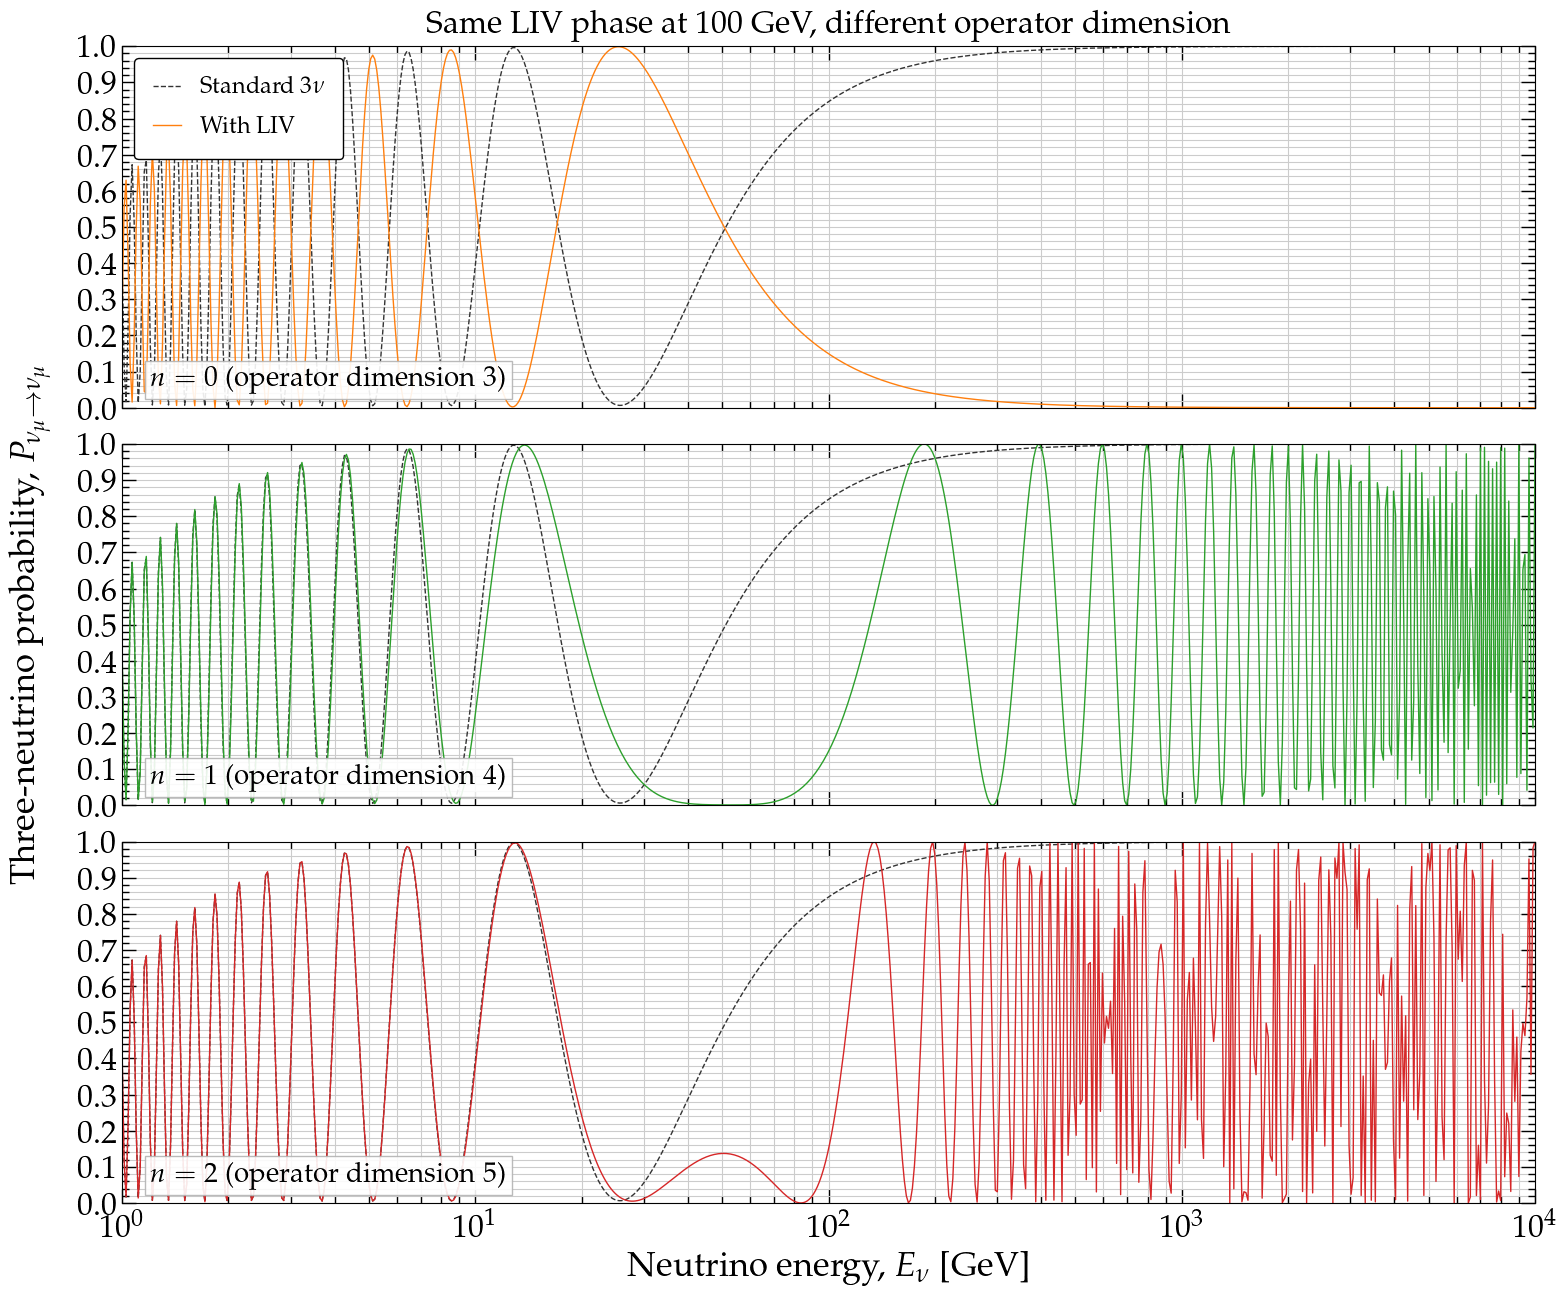

In [6]:
panels = [[dict(y=prob_std, label=r'Standard $3\nu$', color='0.2', ls='--'),
           dict(y=oscprob.osc_prob_3nu_vacuum_liv(E, L, **osc, **liv, b3=b3_for(n),
                                                  n_liv=n, nu_i=nu_i, nu_f=nu_f),
                label=r'With LIV', color='C{:d}'.format(n+1))]
          for n in (0, 1, 2)]

fig, ax = plotting.plot_probability_with_profile(
    energies, None, panels,
    xlim=(energies[0], energies[-1]),
    panel_annotations=[dict(text=r'$n = {:d}$  (operator dimension {:d})'.format(n, n+3),
                            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9))
                       for n in (0, 1, 2)],
    panel_annotation_xy=(0.02, 0.06), panel_annotation_fontsize=20,
    shared_ylabel=r'Three-neutrino probability,~'+plotting.prob_label(nu_i, nu_f),
    xlabel=r'Neutrino energy, $E_\nu$ [GeV]',
    title=r'Same LIV phase at 100~GeV, different operator dimension',
    legend_loc='upper left', legend_kw=dict(framealpha=1.0),
    legend_on_panel=0, figsize=[18, 14])

## 4. LIV inside the Earth

None of the above involved matter. Adding it is a keyword change: the `_liv`
wrappers exist for every environment, so the Earth version takes the same LIV
parameters plus a direction through the PREM profile.

We take an upward-going trajectory, $\cos\theta_z = -1$, which crosses the core
-- the longest baseline and the densest matter available:

/home/mbustamante/Research/magnus/src/magnus/oscprob.py:3821: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  U = magnus.evolution_operator

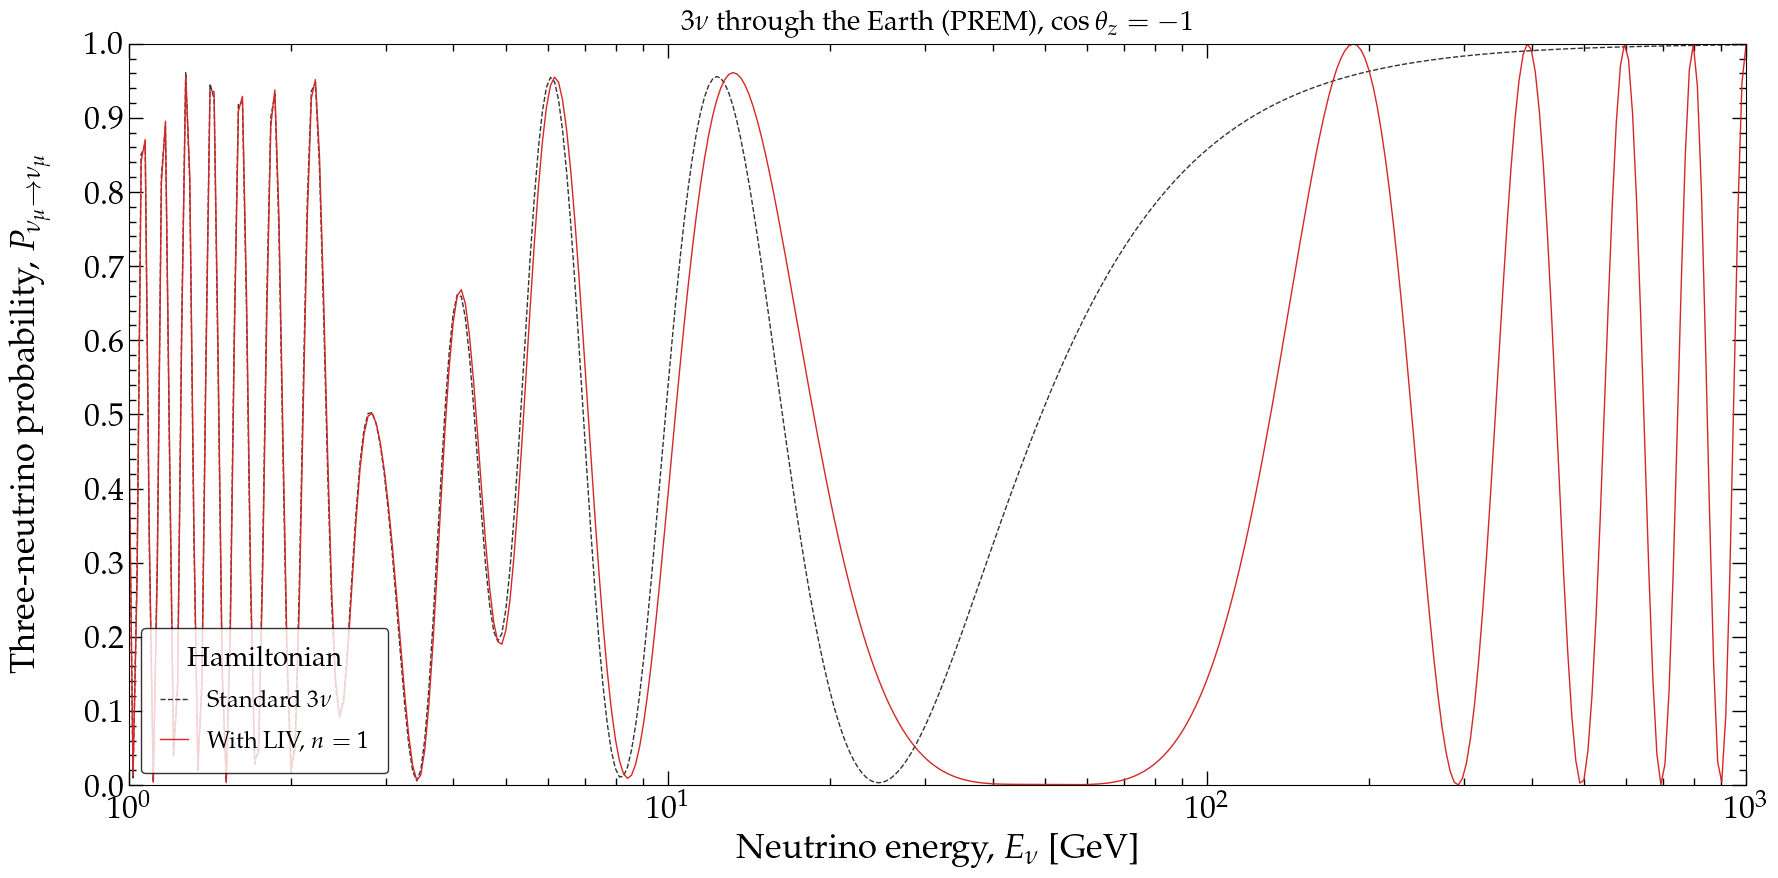

In [7]:
costhz = -1.0                                     # straight up through the core
L_earth = earth.distance_traveled_inside_earth(costhz)*gd.CONV_KM_TO_INV_EV

energies_e = np.logspace(0.0, 3.0, 400)           # [GeV]
E_e = energies_e*gd.UNIT_GEV

prob_earth_std = oscprob.osc_prob_3nu_earth(
    E_e, costhz=costhz, L=L_earth, **osc, nu_i=nu_i, nu_f=nu_f)
prob_earth_liv = oscprob.osc_prob_3nu_earth_liv(
    E_e, costhz=costhz, L=L_earth, **osc, **liv,
    b3=b3_for(1, L=L_earth), n_liv=1, nu_i=nu_i, nu_f=nu_f)

fig, ax = plotting.plot_probability_vs_energy(
    energies_e,
    [dict(y=prob_earth_std, label=r'Standard $3\nu$', color='0.2', ls='--'),
     dict(y=prob_earth_liv, label=r'With LIV, $n = 1$', color='C3')],
    nu_i=nu_i, nu_f=nu_f, num_flavors=3,
    xlim=(energies_e[0], energies_e[-1]),
    legend_title=r'Hamiltonian', legend_loc='lower left',
    title=r'$3\nu$~through the Earth (PREM), $\cos\theta_z = -1$')

The matter term does not rescue the Standard Model curve at high energy.
$V_{\rm CC}$ is a few $\times 10^{-13}$ eV in the core and does not grow with
energy, so once the vacuum phase has shrunk away there is nothing left to make
the probability move -- while the LIV term is still climbing. Matter changes
*where* the standard curve flattens, not *that* it flattens.

## 5. Two flavours, and setting a limit

The two-flavour interface is the same with one angle and two eigenvalues
(`sxi`, `b1`, `b2`), which is often how published constraints are quoted.

Here is the shape of a limit. A detector that sees standard oscillations up to
some energy and no anomaly constrains $b_3$: values large enough to distort the
survival probability there are excluded. We scan $b_3$ at a fixed high energy
and ask how far the probability moves from the standard prediction.

phase reaches 1 radian at b3 = 1.518e-26 eV^0


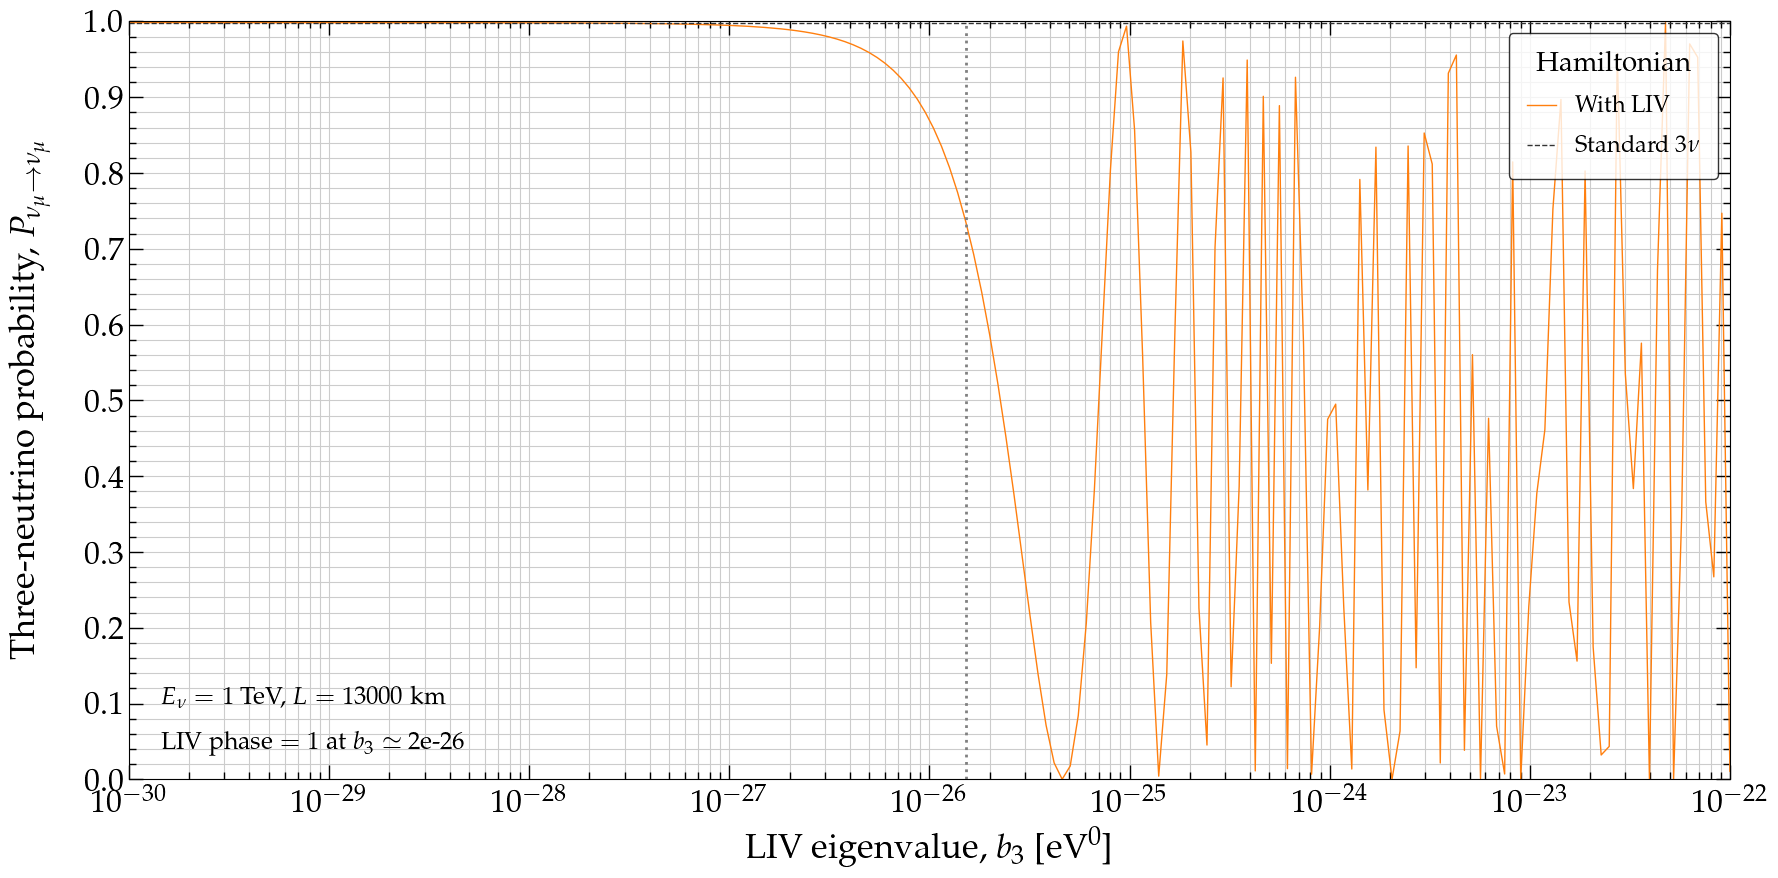

In [8]:
E_probe = 1.0e3*gd.UNIT_GEV            # 1 TeV: standard oscillation is long gone
b3_scan = np.logspace(-30.0, -22.0, 200)

P_std_probe = oscprob.osc_prob_3nu_vacuum(E_probe, L, **osc, nu_i=nu_i, nu_f=nu_f)
P_scan = np.array([
    oscprob.osc_prob_3nu_vacuum_liv(E_probe, L, **osc, **liv, b3=b, n_liv=1,
                                    nu_i=nu_i, nu_f=nu_f)
    for b in b3_scan])

# The value at which the LIV phase reaches one radian -- the scale a
# null result excludes above.
b3_sensitivity = 1.0/(L*E_probe)

fig, ax = plotting.plot_curves(
    b3_scan,
    [dict(y=P_scan, label=r'With LIV', color='C1'),
     dict(y=np.full_like(b3_scan, P_std_probe), label=r'Standard $3\nu$',
          color='0.2', ls='--')],
    xlabel=r'LIV eigenvalue, $b_3$ [eV$^0$]',
    ylabel=r'Three-neutrino probability,~'+plotting.prob_label(nu_i, nu_f),
    xlim=(b3_scan[0], b3_scan[-1]), ylim=(0, 1), xscale='log',
    ymajor=0.10, yminor=0.02,
    annotations=[dict(text=r'$E_\nu = 1$~TeV, $L = $~{:.0f}~km'.format(L_km),
                      xy=(0.02, 0.10), fontsize=18),
                 dict(text=r'LIV phase $= 1$ at $b_3 \simeq $ '
                           + '{:.0e}'.format(b3_sensitivity),
                      xy=(0.02, 0.04), fontsize=18)],
    legend_title=r'Hamiltonian', legend_loc='upper right', grid=True)

ax.axvline(b3_sensitivity, color='0.5', ls=':', lw=2)

print(f'phase reaches 1 radian at b3 = {b3_sensitivity:.3e} eV^0')

Below that value the curve sits on the standard prediction and a measurement
says nothing; above it the probability departs and a null result excludes the
parameter. The vertical line is not a fit -- it is just $b_3 L E = 1$, and it
lands where the curve visibly leaves the dashed line, which is the useful
sanity check on any sensitivity estimate of this kind.

Note how the reach improves: the excluded $b_3$ scales as $1/(LE^n)$, so for
$n \geq 1$ going to higher energy buys sensitivity faster than going to longer
baseline. That is the reason astrophysical neutrinos, not longer beamlines,
set the strongest limits on the higher-dimension operators.

## Where to go next

* `magnus.oscprob` has `_liv` wrappers for 2, 3, 4 and 5 flavours and for every
  environment; sterile states and LIV can be switched on together.
* The same `strategy`, `average` and tolerance keywords documented elsewhere
  apply here unchanged -- LIV is a term in the Hamiltonian, not a separate code
  path.
* `notebooks/08_magnus_bsm_nsi.ipynb` covers the other BSM scenario, where the
  new term is tied to matter rather than to energy.

---

**Previous:** [BSM: non-standard interactions](08_magnus_bsm_nsi.ipynb)  
**Next:** [Phase-averaged probabilities](10_magnus_averaged_probability.ipynb) --- what survives when the phase is unresolvable  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)